In [ ]:
import numpy as np
from gpcam import GPOptimizer

import matplotlib.pyplot as plt

import plotly.graph_objects as go
import networkx as nx


from scipy.spatial.distance import cdist


import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

# Using Data Extracted from the Firedrake environment

In [ ]:
# Load everything
all_geodesic_distances = np.load('Data/teddy_exact_geodesic_distances_graph.npy') # ('teddy_geodesic_distances.npy')
vertices = np.load('Data/teddy_vertices.npy')
faces = np.load('Data/teddy_faces.npy')
y_values = np.load('Data/teddy_y_values.npy')

print("Done")

Done


In [3]:

# Create mesh plot with y-values as colors
fig = go.Figure(data=[
    go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        intensity=y_values,  # Color by y-values
        colorscale='Viridis',  # Or 'RdBu', 'Plasma', etc.
        colorbar=dict(title="Y value"),
        showscale=True
    )
])

# Clean up the figure (using your update_figure function)
fig.update_layout(scene_aspectmode="auto")
fig.update_scenes(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.update_layout(
    scene_camera=dict(
        up=dict(x=0, y=1, z=0),
        center=dict(x=0, y=0, z=0),
        eye=dict(x=0, y=0.7, z=1.25)
    )
)

fig.show()

# Running One GP Model Training

In [10]:
# Step 1: First sample the subset of points
np.random.seed(3256)

# Step 3: Now split the subset into train and test
n_train = 50
n_test = 50

# Sample ALL indices at once, then split
indices_all = np.random.choice(len(vertices), size=n_train + n_test, replace=False)

# Split into train and test
indices_train = indices_all[:n_train]
indices_test = indices_all[n_train:]

# Extract data
#x_train = vertices[indices_train,:]
x_train = indices_train.reshape(-1,1)
y_train = y_values[indices_train]

# x_test = vertices[indices_test,:]
x_test = indices_test.reshape(-1,1)
y_test = y_values[indices_test]

print(f"Training points: {len(indices_train)}")
print(f"Test points: {len(indices_test)}")

indices_train_sort = np.sort(indices_train)


Training points: 50
Test points: 50


In [ ]:
# Step 2 (Fixed): Define the basic GP components
def matern_kernel_diff2(distance, length):
    kernel = (1.0
                 + ((np.sqrt(5.0) * distance) / (length))
                 + ((5.0 * distance ** 2) / (3.0 * length ** 2))
             ) * np.exp(-(np.sqrt(5.0) * distance) / length)
    return kernel

def bump(d, r, beta, ampl):
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values

def bump_k(x1, x2, hps):

    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    # Extract geodesic distances
    # d1: distances from x1 points to training points
    d1 = all_geodesic_distances[np.ix_(x1_idx, indices_train)]  # Shape: (len(x1), n_train)
    d2 = all_geodesic_distances[np.ix_(x2_idx, indices_train)]  # Shape: (len(x2), n_train)
    
    # Apply bump to create embedding
    phi_x1 = bump(d1, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x1), n_train)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x2), n_train)
    
    # Matern on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
    
    return hps[0] * matern_kernel_diff2(D_mat, hps[3])


def my_noise(x, hps):
    s = np.ones(len(x)) * hps[4]
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0 # hps[4]
    return m

In [12]:
# 1. Signal variance (hps[0]): [0.01 * y_var, 10 * y_var]
y_var = np.var(y_train)

# 2. Bump radius (hps[1]): [min distance, maximum distance]
train_geodesic = all_geodesic_distances[np.ix_(x_train.flatten(), x_train.flatten())]
non_zero_dists = train_geodesic[train_geodesic > 0]

# Define hyperparameter bounds
bounds = np.empty((5, 2))
bounds[0] = np.array([1e2, 1e6])   # 1e6                                     # sigma_f: signal variance      
bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # bump radius
bounds[2] = np.array([1e-1,50])                                              # bump amplitude
bounds[3] = np.array([1e-3, 50])                                             # Exponential lengthscale
#bounds[4] = np.array([1e-5, 1])                                             # bump beta
bounds[4] = np.array([1e-6, 10])                                             # Noise variance

print(f"\nHyperparameter bounds:")
print(f"  Signal variance: [{bounds[0, 0]:.6f}, {bounds[0, 1]:.6f}]")
print(f"  Bump radius:     [{bounds[1, 0]:.6f}, {bounds[1, 1]:.6f}]")
print(f"  Bump Amplitude:  [{bounds[2, 0]:.6f}, {bounds[2, 1]:.6f}]")
print(f"  RBF length:      [{bounds[3, 0]:.6f}, {bounds[3, 1]:.6f}]")
#print(f"  Bump Beta:       [{bounds[4, 0]:.6f}, {bounds[4, 1]:.6f}]")
print(f"  Noise Variance:  [{bounds[4, 0]:.6f}, {bounds[4, 1]:.6f}]")


Hyperparameter bounds:
  Signal variance: [100.000000, 1000000.000000]
  Bump radius:     [0.370138, 54.730736]
  Bump Amplitude:  [0.100000, 50.000000]
  RBF length:      [0.001000, 50.000000]
  Noise Variance:  [0.000001, 10.000000]


In [13]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)


print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(x_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_k,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")

# Step 5: Train the GP model
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global')#, max_iter=15000)

# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")

# Final hyperparameters:   [8.27802483e+01 7.58312895e-01 4.99824805e+02 1.81358351e-02 1.07441620e-01]  # Test RMSE: 0.42


Initial hyperparameters: [5.0005000e+05 2.7550437e+01 2.5050000e+01 2.5000500e+01 5.0000005e+00]
Initial log likelihood: -350.347677
Final hyperparameters:   [5.77770367e+03 3.18682924e+01 4.24881617e+01 2.09730538e+01
 1.78685043e-01]
Final log likelihood:    -277.33


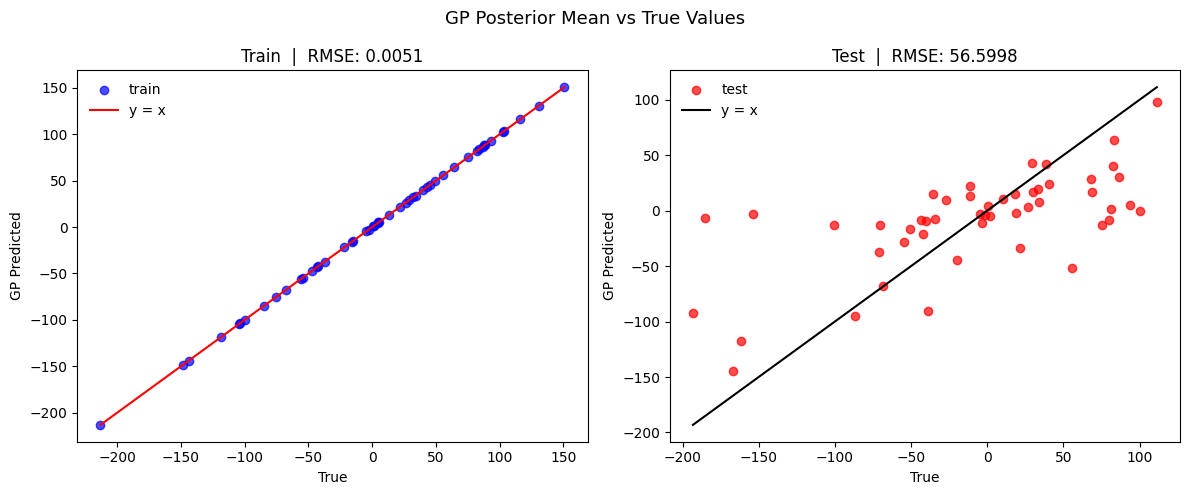

Train RMSE: 0.0051
Test  RMSE: 56.5998


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Train ──────────────────────────────────────────────────────────────
f_train = my_gpo.posterior_mean(x_train)["m(x)"]
rmse_train = my_gpo.rmse(x_train, y_train)

my_line_train = np.linspace(np.min(y_train), np.max(y_train), 10)

axes[0].scatter(y_train, f_train, color="blue", label="train", alpha=0.7)
axes[0].plot(my_line_train, my_line_train, c="red", label="y = x")
axes[0].set_xlabel("True")
axes[0].set_ylabel("GP Predicted")
axes[0].set_title(f"Train  |  RMSE: {rmse_train:.4f}")
axes[0].legend(frameon=False)

# ── Right: Test ───────────────────────────────────────────────────────────────
f_test = my_gpo.posterior_mean(x_test)["m(x)"]
rmse_test = my_gpo.rmse(x_test, y_test)

my_line_test = np.linspace(np.min(y_test), np.max(y_test), 10)

axes[1].scatter(y_test, f_test, color="red", label="test", alpha=0.7)
axes[1].plot(my_line_test, my_line_test, c="black", label="y = x")
axes[1].set_xlabel("True")
axes[1].set_ylabel("GP Predicted")
axes[1].set_title(f"Test  |  RMSE: {rmse_test:.4f}")
axes[1].legend(frameon=False)

plt.suptitle("GP Posterior Mean vs True Values", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}")

# Making several trials with different training size

In [ ]:
import json
from tqdm import tqdm

import numpy as np
from gpcam import GPOptimizer

import os

from scipy.spatial.distance import cdist
from scipy.stats import norm

import time

import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

In [ ]:
# Load everything
all_geodesic_distances = np.load('Data/teddy_exact_geodesic_distances_graph.npy')
vertices = np.load('Data/teddy_vertices.npy')
faces = np.load('Data/teddy_faces.npy')
y_values = np.load('Data/teddy_y_values.npy')

print("Done")

Done


In [5]:
def my_noise(x, hps):
    s = np.ones(len(x)) * hps[4]  # hps[3]
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0 # hps[4]
    return m

In [ ]:
def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"📂 Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("🆕 Creating new results file")
                return []
    else:
        print("🆕 Creating new results file")
        return []

def get_test_data(configs, vertices, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    #x_test = vertices[test_indices]
    x_test = np.array(test_indices).reshape(-1,1)
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, vertices, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    #x_train = vertices[indices_train]
    x_train = np.array(indices_train).reshape(-1,1)
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed, indices_train

def get_hps_bounds(indices_train):
    
    # 2. Bump radius (hps[1]): [min distance, maximum distance]
    train_geodesic = all_geodesic_distances[np.ix_(indices_train, indices_train)]
    non_zero_dists = train_geodesic[train_geodesic > 0]
    
    # Define hyperparameter bounds
    bounds = np.empty((5, 2))
    bounds[0] = np.array([1e2, 1e6])   # 1e6                                     # sigma_f: signal variance      
    bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # bump radius
    bounds[2] = np.array([1e-1,10])                                              # bump amplitude
    bounds[3] = np.array([1e-3, 40])                                             # Exponential lengthscale
    bounds[4] = np.array([1e-6,10])                                              # Noise variance
    return bounds


def matern_kernel_diff2(distance, length):
    kernel = (1.0
                 + ((np.sqrt(5.0) * distance) / (length))
                 + ((5.0 * distance ** 2) / (3.0 * length ** 2))
             ) * np.exp(-(np.sqrt(5.0) * distance) / length)
    return kernel
    
def train_gp_model(x_train, y_train, bounds):
    """Train GP model with your existing setup"""
    
    # Initial hyperparameters (middle of bounds)
    init_hps = np.mean(bounds, axis=1)


    def bump(d, r, beta, ampl):
        """
        Bump function for the kernel
        d: distances (can be any shape)
        r: radius parameter. Identifies the cutoff after which the covariance becomes 0 when beta=0
        beta: shape parameter. 0 results in a square-like function, larger values cause faster decay
        ampl: amplitude
        """
        a = 1.0 - (d**2 / r**2)
        bump_values = np.zeros_like(a)
        
        # Only compute where a > 0
        positive_mask = a > 0.0
        if np.any(positive_mask):
            e = np.exp((-beta / a[positive_mask]) + beta)
            bump_values[positive_mask] = ampl * e
        
        return bump_values
    
    def bump_k_multiple_trials(x1, x2, hps):
    
        # x1 and x2 ARE the indices - just extract them
        x1_idx = x1.astype(int).flatten()
        x2_idx = x2.astype(int).flatten()
        
        # Extract geodesic distances
        # d1: distances from x1 points to training points
        # We want shape: (len(x1), n_train) - each row is one x1 point's distances to all training points
        d1 = all_geodesic_distances[np.ix_(x1_idx, indices_train_trials)]  # Shape: (len(x1), n_train)
        d2 = all_geodesic_distances[np.ix_(x2_idx, indices_train_trials)]  # Shape: (len(x2), n_train)
        
        # Apply bump to create embedding
        # phi_x1[i, :] = embedding of x1[i] based on distances to all training points
        phi_x1 = bump(d1, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x1), n_train)
        phi_x2 = bump(d2, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x2), n_train)
        
        # Matern on embeddings
        D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
        
        #return hps[0] * np.exp(-D_mat**2 / hps[3]) #, D_mat
        return hps[0] * matern_kernel_diff2(D_mat, hps[3])
    
    # Initialize GPOptimizer
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=bump_k_multiple_trials,
                         prior_mean_function=my_mean, 
                         noise_function=my_noise)
    
    # Train the GP model
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='global', 
                 max_iter=4000)
    
    return my_gpo

def picp(gp_model_object, x_test, y_true, interval=0.95):
        mu = gp_model_object.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(gp_model_object.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
   

def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, train_size, trial_idx):
    """Check if this experiment was already completed"""
    for result in existing_results:
        if (result.get('training_size') == train_size and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_complete_gp_experiments():
    """Run all GP experiments and save results incrementally"""
    
    # Load configurations
    print("Loading configurations...")
    json_file_name = 'teddy_example_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    # Load existing results or create new
    results_filename = 'teddy_results_SLE_Kernel.json'
    all_results = load_or_create_results_file(results_filename)
    
    # Get fixed test data
    #print("Loading test data...")
    x_test, y_test = get_test_data(configs, vertices, y_values)
    print(f"Test data shape: x: {x_test.shape}, y: {y_test.shape}")
    
    # Get all training sizes
    training_sizes = list(configs['training_configurations'].keys())
    training_sizes = [int(size) for size in training_sizes]
    training_sizes.sort()
    
    # Main experiment loop
    for train_size in training_sizes:
        print(f"\n=== Training Size: {train_size} ===")
        
        trials = configs['training_configurations'][str(train_size)]
        
        #for trial_idx in tqdm(range(len(trials)), desc=f"Size {train_size}"):
        for trial_idx in tqdm(range(30), desc=f"Size {train_size}"):
    
            # Skip if already completed
            if check_if_already_done(all_results, train_size, trial_idx):
                print(f"Skipping trial {trial_idx} (already completed)")
                continue
            
            try:
                # Get training data for this trial
                x_train, y_train, seed, indices_train_trials = get_training_data(configs, train_size, trial_idx, vertices, y_values)

                ##################
                # Make x_train global so kernel functions can access it
                globals()['x_train'] = x_train  
                globals()['y_train'] = y_train
                globals()['indices_train_trials'] = indices_train_trials  
                ##################
                

                # Identify the hps bounds
                bounds_trials = get_hps_bounds(indices_train_trials)

                # Train GP model
                my_gpo = train_gp_model(x_train, y_train, bounds_trials)
                
                # Calculate training RMSE
                train_rmse = my_gpo.rmse(x_train, y_train)
                
                # Calculate testing RMSE
                test_rmse = my_gpo.rmse(x_test, y_test)

                # Compute CRPS
                crps_test = my_gpo.crps(x_test, y_test)

                # Compute picp
                picp_test = picp(my_gpo, x_test, y_test)

                # Get final hyperparameters and log likelihood
                final_hps = my_gpo.get_hyperparameters()
                final_ll = my_gpo.log_likelihood(final_hps)
                
                # Store results
                result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'test_crps mean': float(crps_test[0]),
                    'test_crps std': float(crps_test[1]),
                    'test_picp': float(picp_test),
                    'final_log_likelihood': float(final_ll),
                    'final_hyperparameters': final_hps.tolist(),
                    'n_training_points': len(x_train),
                }
                
                all_results.append(result)
                
                # Save after each trial
                save_results_incremental(all_results, results_filename)
                
                # Print progress for first few trials
                if trial_idx < 3:
                    print(f"Trial {trial_idx}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f} Saved")
                
            except Exception as e:
                print(f"Trial {trial_idx} failed: {str(e)}")
                
                # Save failed result too
                failed_result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("Starting GP experiments...")
print("="*60)

# Run experiments
results = run_complete_gp_experiments()

print("="*60)
print(f"Completed! Total experiments: {len(results)}")